In [75]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

sys.path.append("../")
from utils.io import read_parameters
from src.plot_trajectories import normalize_speed
#from src.plot_trajectories import plot_trajectories

cmap = matplotlib.colormaps["seismic_r"]



In [90]:
# Load parameters and key file
parameter_file  = "../local_new/parameters_mosaic.yml"
parameters = read_parameters(parameter_file)    

key_file_path = parameters["key_file"]
key_file = pd.read_csv(key_file_path)

print("key file columns:", key_file.columns)
print("key file conditions:", key_file["condition"].unique())
print(display(key_file))


base_folder = parameters["base_folder"]
output_folder = parameters["output_folder"]
print("Output folder:", output_folder)

frames_per_hour = parameters["frames_per_hour"]


key file columns: Index(['experimentID', 'filename', 'color', 'mosaic', 'treatment', 'condition',
       'date'],
      dtype='object')
key file conditions: ['mosaic_siCTRL_siCTRL' 'mosaic_siCTRL_siAlk1' 'mosaic_siCTRL_siSMAD4']


,experimentID,filename,color,mosaic,treatment,condition,date
0,230901_siCTRL_1_mosaic,Z:/02_Projects/Manuscript_Goldilocks_HHT/v2024...,green,1,siCTRL,mosaic_siCTRL_siCTRL,230901
1,230901_siCTRL_1_mosaic,Z:/02_Projects/Manuscript_Goldilocks_HHT/v2024...,red,1,siCTRL,mosaic_siCTRL_siCTRL,230901
2,230901_siCTRL_2_mosaic,Z:/02_Projects/Manuscript_Goldilocks_HHT/v2024...,green,1,siCTRL,mosaic_siCTRL_siCTRL,230901
3,230901_siCTRL_2_mosaic,Z:/02_Projects/Manuscript_Goldilocks_HHT/v2024...,red,1,siCTRL,mosaic_siCTRL_siCTRL,230901
4,230922_siCTRL_1_mosaic,Z:/02_Projects/Manuscript_Goldilocks_HHT/v2024...,green,1,siCTRL,mosaic_siCTRL_siCTRL,230922
5,230922_siCTRL_1_mosaic,Z:/02_Projects/Manuscript_Goldilocks_HHT/v2024...,red,1,siCTRL,mosaic_siCTRL_siCTRL,230922
6,230922_siCTRL_2_mosaic,Z:/02_Projects/Manuscript_Goldilocks_HHT/v2024...,green,1,siCTRL,mosaic_siCTRL_siCTRL,230922
7,230922_siCTRL_2_mosaic,Z:/02_Projects/Manuscript_Goldilocks_HHT/v2024...,red,1,siCTRL,mosaic_siCTRL_siCTRL,230922
8,230804_siCTRL_siAlk1,Z:/02_Projects/Manuscript_Goldilocks_HHT/v2024...,red,1,siAlk1,mosaic_siCTRL_siAlk1,230804
9,230804_siCTRL_siAlk1,Z:/02_Projects/Manuscript_Goldilocks_HHT/v2024...,green,1,siCTRL,mosaic_siCTRL_siAlk1,230804


None
Output folder: Z:/02_Projects/Manuscript_Goldilocks_HHT/v2024/Figure_4/data_analysis/mosaic/output/proportions


In [91]:
frames_per_hour = parameters["frames_per_hour"]

# Define time windows
time_windows = [
    (8, 80),
    (80, 160),
    (160, 240),
    (240, 320),
    (320, 400),
    (400, 480)
]
window_labels = [f"{s//frames_per_hour}-{e//frames_per_hour}h" for s, e in time_windows]

def classify_migration_direction(dx, dy):
    angle = np.degrees(np.arctan2(dy, dx)) % 360
    if 135 <= angle <= 225:
        return "against"
    elif (0 <= angle <= 45) or (315 <= angle <= 360):
        return "with"
    else:
        return "perpendicular"

# Build per-experiment proportions for mosaic data
mosaic_props = []

for _, row in key_file.iterrows():
    try:
        condition = row["condition"].strip()
        experiment_id = row["experimentID"]
        color = row["color"]
        file_path = os.path.join(parameters["base_folder"], row["filename"])
        df = pd.read_csv(file_path)

        for (start_frame, end_frame), label in zip(time_windows, window_labels):
            df_window = df[(df["FRAME"] >= start_frame) & (df["FRAME"] <= end_frame)]

            track_counts = {"with": 0, "against": 0, "perpendicular": 0}
            for track_id in df_window["TRACK_ID"].unique():
                track = df_window[df_window["TRACK_ID"] == track_id]
                if track["FRAME"].min() != start_frame or track["FRAME"].max() != end_frame:
                    continue

                start = track[track["FRAME"] == start_frame].iloc[0]
                end = track[track["FRAME"] == end_frame].iloc[0]
                dx = end["POSITION_X"] - start["POSITION_X"]
                dy = end["POSITION_Y"] - start["POSITION_Y"]
                direction = classify_migration_direction(dx, dy)
                track_counts[direction] += 1

            total = sum(track_counts.values())
            if total == 0:
                continue

            for direction in ["with", "against", "perpendicular"]:
                prop = track_counts[direction] / total
                mosaic_props.append({
                    "experimentID": experiment_id,
                    "condition": condition,
                    "color": color,
                    "time_window": label,
                    "direction": direction,
                    "proportion": prop
                })

    except Exception as e:
        print(f"❌ Error in {row['filename']}: {e}")

df_mosaic_props = pd.DataFrame(mosaic_props)


In [92]:
from scipy.stats import ttest_ind

# Define comparisons vs control
reference_condition = "mosaic_siCTRL_siCTRL"
compare_conditions = ["mosaic_siCTRL_siSMAD4", "mosaic_siCTRL_siAlk1"]
directions = ["with", "against", "perpendicular"]

results = []

for color in df_mosaic_props["color"].unique():
    for direction in directions:
        for time in sorted(df_mosaic_props["time_window"].unique(), key=lambda x: int(x.split("-")[0])):
            for test_condition in compare_conditions:
                ref_group = df_mosaic_props[
                    (df_mosaic_props["condition"] == reference_condition) &
                    (df_mosaic_props["color"] == color) &
                    (df_mosaic_props["time_window"] == time) &
                    (df_mosaic_props["direction"] == direction)
                ]["proportion"]

                test_group = df_mosaic_props[
                    (df_mosaic_props["condition"] == test_condition) &
                    (df_mosaic_props["color"] == color) &
                    (df_mosaic_props["time_window"] == time) &
                    (df_mosaic_props["direction"] == direction)
                ]["proportion"]

                # Perform Welch's t-test if both groups have >=2 values
                if len(ref_group) >= 2 and len(test_group) >= 2:
                    stat, pval = ttest_ind(test_group, ref_group, equal_var=False)
                else:
                    stat, pval = None, None

                results.append({
                    "color": color,
                    "time_window": time,
                    "direction": direction,
                    "compare": f"{test_condition} vs {reference_condition}",
                    "mean_ref": ref_group.mean() if len(ref_group) else None,
                    "sem_ref": ref_group.sem() if len(ref_group) >= 2 else None,
                    "mean_test": test_group.mean() if len(test_group) else None,
                    "sem_test": test_group.sem() if len(test_group) >= 2 else None,
                    "t_stat": stat,
                    "p_value": pval
                })

# Build DataFrame
df_mosaic_stats = pd.DataFrame(results)


In [93]:
from IPython.display import display

display(df_mosaic_stats.head(10))

# Optional: Save
outpath = os.path.join(parameters["output_folder"], "mosaic_welch_stats.csv")
df_mosaic_stats.to_csv(outpath, index=False)
print(f"✅ Welch's t-test results saved to: {outpath}")


,color,time_window,direction,compare,mean_ref,sem_ref,mean_test,sem_test,t_stat,p_value
0,green,1-10h,with,mosaic_siCTRL_siSMAD4 vs mosaic_siCTRL_siCTRL,0.225651,0.065185,0.130464,0.013957,-1.427901,0.241333
1,green,1-10h,with,mosaic_siCTRL_siAlk1 vs mosaic_siCTRL_siCTRL,0.225651,0.065185,0.318504,0.065548,1.004441,0.353941
2,green,10-20h,with,mosaic_siCTRL_siSMAD4 vs mosaic_siCTRL_siCTRL,0.257294,0.008191,0.072907,0.021364,-8.058859,0.001489
3,green,10-20h,with,mosaic_siCTRL_siAlk1 vs mosaic_siCTRL_siCTRL,0.257294,0.008191,0.225464,0.035125,-0.882514,0.436650
4,green,20-30h,with,mosaic_siCTRL_siSMAD4 vs mosaic_siCTRL_siCTRL,0.335150,0.059048,0.048922,0.005305,-4.827892,0.016324
5,green,20-30h,with,mosaic_siCTRL_siAlk1 vs mosaic_siCTRL_siCTRL,0.335150,0.059048,0.220025,0.042696,-1.579926,0.170016
6,green,30-40h,with,mosaic_siCTRL_siSMAD4 vs mosaic_siCTRL_siCTRL,0.237851,0.075270,0.040319,0.021591,-2.522572,0.074239
7,green,30-40h,with,mosaic_siCTRL_siAlk1 vs mosaic_siCTRL_siCTRL,0.237851,0.075270,0.107681,0.034728,-1.570289,0.187720
8,green,40-50h,with,mosaic_siCTRL_siSMAD4 vs mosaic_siCTRL_siCTRL,0.111232,0.025123,0.008419,0.003646,-4.049921,0.025071
9,green,40-50h,with,mosaic_siCTRL_siAlk1 vs mosaic_siCTRL_siCTRL,0.111232,0.025123,0.056875,0.026300,-1.494497,0.185769


✅ Welch's t-test results saved to: Z:/02_Projects/Manuscript_Goldilocks_HHT/v2024/Figure_4/data_analysis/mosaic/output/proportions\mosaic_welch_stats.csv


In [94]:
# Compute mean and SEM per condition, time window, direction, and color
df_sem_mosaic = (
    df_mosaic_props
    .groupby(["condition", "color", "time_window", "direction"])["proportion"]
    .agg(['mean', 'sem'])  # sem = standard error of the mean
    .reset_index()
)


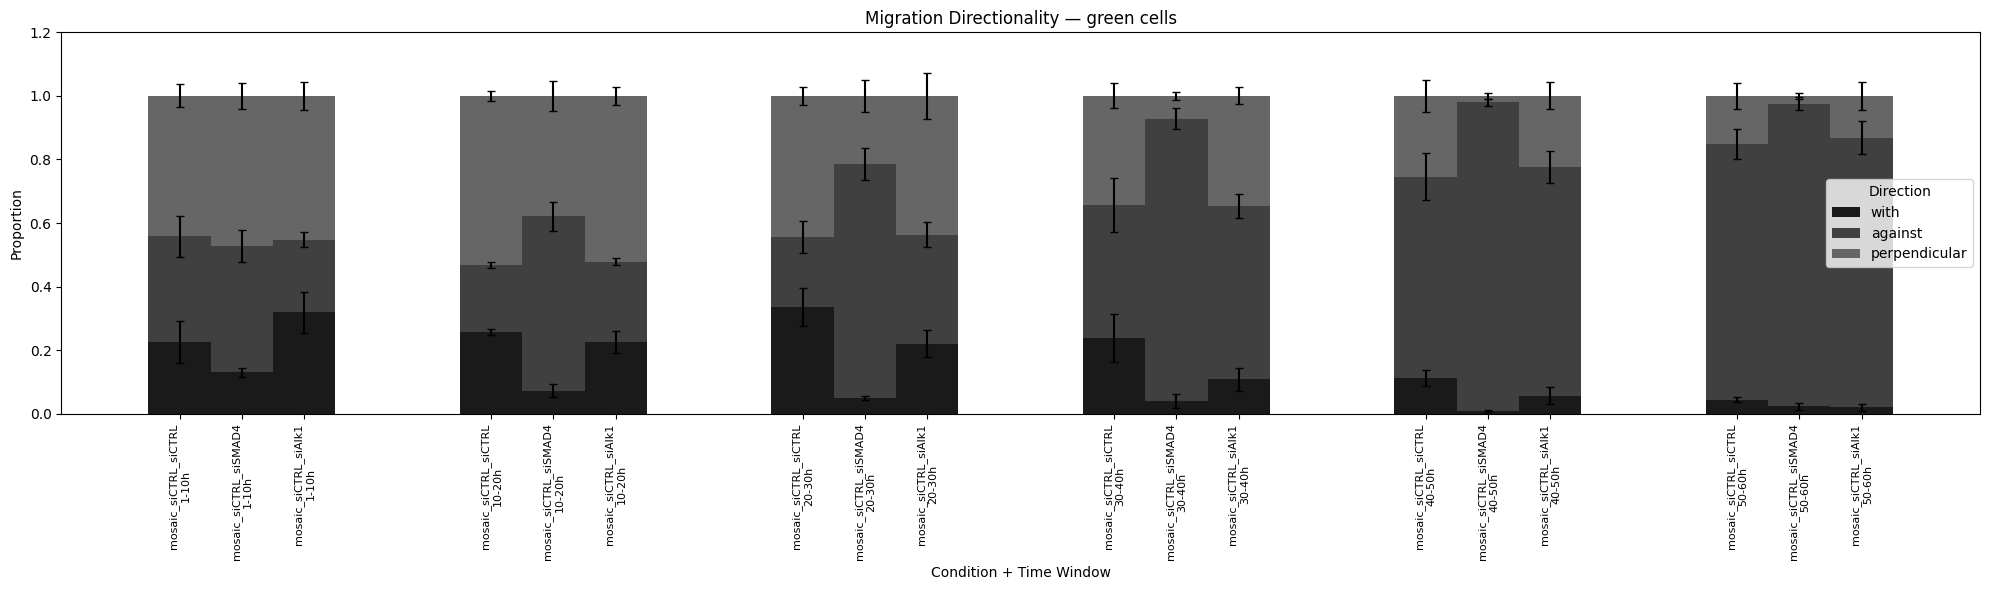

✅ Saved to: Z:/02_Projects/Manuscript_Goldilocks_HHT/v2024/Figure_4/data_analysis/mosaic/output/proportions\proportions\mosaic_directionality_green.pdf


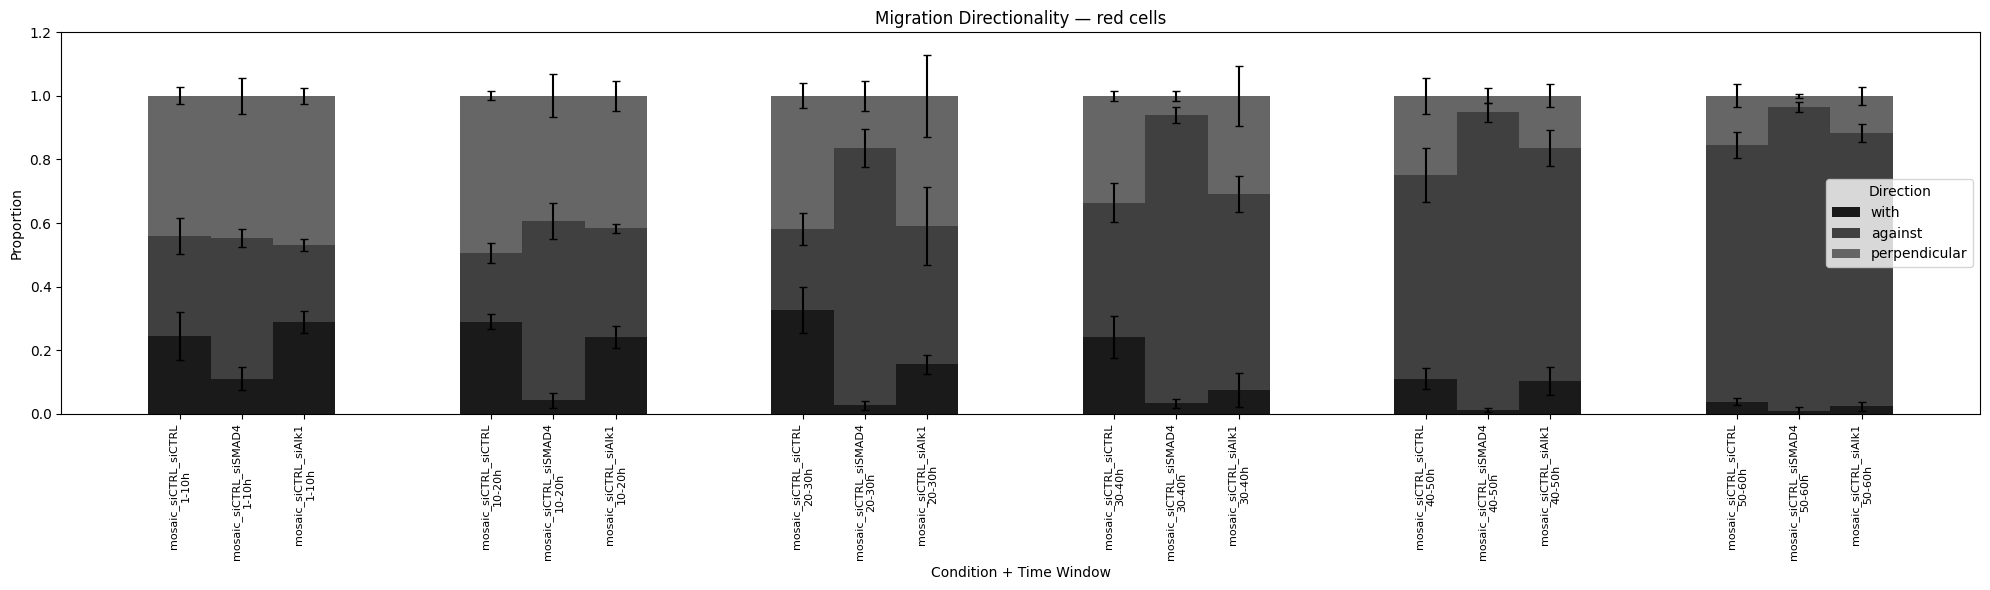

✅ Saved to: Z:/02_Projects/Manuscript_Goldilocks_HHT/v2024/Figure_4/data_analysis/mosaic/output/proportions\proportions\mosaic_directionality_red.pdf


In [96]:
# Ensure SEM data is built
sem_mean_dict = df_sem_mosaic.set_index(["condition", "color", "time_window", "direction"])["mean"].to_dict()
sem_sem_dict = df_sem_mosaic.set_index(["condition", "color", "time_window", "direction"])["sem"].to_dict()

# Use df_sem_mosaic instead of df_long_mosaic to drive the loop
for color in df_sem_mosaic["color"].unique():
    df_color = df_sem_mosaic[df_sem_mosaic["color"] == color]

    # Plot settings
    bar_width = 0.25
    inter_group_spacing = 0.5
    colors_map = {"with": "#1A1A1A", "against": "#404040", "perpendicular": "#666666"}
    conditions = parameters["condition_order"]
    time_windows = sorted(df_color["time_window"].unique(), key=lambda x: int(x.split("-")[0]))

    # Calculate x positions
    x_positions = []
    bar_labels = []
    tick_positions = []

    current_x = 0
    for time in time_windows:
        group_x = []
        for condition in conditions:
            x_positions.append(current_x)
            bar_labels.append(f"{condition}\n{time}")
            group_x.append(current_x)
            current_x += bar_width
        tick_positions.append(np.mean(group_x))
        current_x += inter_group_spacing

    x = np.array(x_positions)
    fig, ax = plt.subplots(figsize=(20, 6))
    bottom = np.zeros_like(x, dtype=float)

    # Plot stacked bars with SEM
    for d in ["with", "against", "perpendicular"]:
        height = []
        error = []
        i = 0
        for time in time_windows:
            for condition in conditions:
                key = (condition, color, time, d)
                mean = sem_mean_dict.get(key, 0)
                sem = sem_sem_dict.get(key, 0)
                height.append(mean)
                error.append(sem)

                if mean == 0:
                    print(f"[WARN] No data for {key} — bar will be empty.")

                i += 1

        height = np.array(height)
        error = np.array(error)

        ax.bar(x, height, bar_width, bottom=bottom, color=colors_map[d], label=d)
        ax.errorbar(x, bottom + height, yerr=error, fmt='none',
                    ecolor='black', capsize=3, linewidth=1.5)
        bottom += height

    # Final touches
    ax.set_xticks(x)
    ax.set_xticklabels(bar_labels, rotation=90, fontsize=8)
    ax.set_xlabel("Condition + Time Window")
    ax.set_ylabel("Proportion")
    ax.set_title(f"Migration Directionality — {color} cells")
    ax.legend(title="Direction")
    plt.ylim(0, 1.2)
    plt.tight_layout()

    # Save
    output_path = os.path.join(parameters["output_folder"], "proportions", f"mosaic_directionality_{color}.pdf")
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    fig.savefig(output_path, format="pdf", bbox_inches="tight")
    plt.show()

    print(f"✅ Saved to: {output_path}")

